In [1]:
import numpy as np
import sympy as sp

In [2]:
def resultado_interpolacion(x_busqueda, x_inicial, y_inicial, x_final, y_final):
    """
    EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
    
    Permite calcular una propiedad intermedia entre datos tabulados de propiedades termodinámicas
    
    Datos de entrada:
    - x_busqueda : valor de la variable independiente para el cual se desea estimar la propiedad (por ejemplo T o P).
    - x_inicial : valor inferior conocido de la variable independiente.
    - y_inicial : valor de la propiedad correspondiente a x_inicial.
    - x_final : valor superior conocido de la variable independiente.
    - y_final : valor de la propiedad correspondiente a x_final.
    
    Retorna:
    - valor_propiedad_x : el valor de la propiedad intermedia entre estado f y g a condiciones dadas de T y P.
    
    """
    m = (y_final-y_inicial)/(x_final-x_inicial)
    resultado = m*(x_busqueda-x_inicial) + y_inicial
    return resultado

# Pagina 225 , 10 - Kenneth Wark

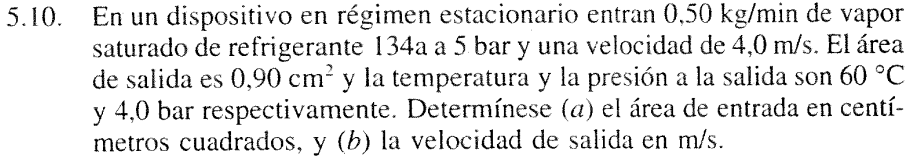

In [3]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales - Vapor saturado R134 - A
m_in = 0.5 * (1/60)      # kg/s
P_in = 5 * (100000)      # Pa
vel_in = 4               # m/s

#   Condiciones finales
A_out = 0.9 * (1/(100**2)) # m²
T_out = 60 + 273.15        # K
P_out = 4 * (100000)       # Pa 

#   Desarrollo - régimen estacionario

#   Objetivos : A_in [=] cm² ; vel_out [=] m/s
vesp_in = 0.0409 # m³ / kg
A_in = (vesp_in * m_in) / vel_in
A_in_cm2 = A_in * ((100**2))
print(f"El area de entrada es {A_in_cm2:,.4f} cm²")

vesp_out = 0.06405 # m³ / kg
vel_out = (A_in * vel_in * vesp_out) / (vesp_in * A_out)
print(f"La velocidad de salida es {vel_out:,.4f} m/s")

Realizado por Exergia Code : 
El area de entrada es 0.8521 cm²
La velocidad de salida es 5.9306 m/s


# Pagina 252 ,10 - Çengel Yunus

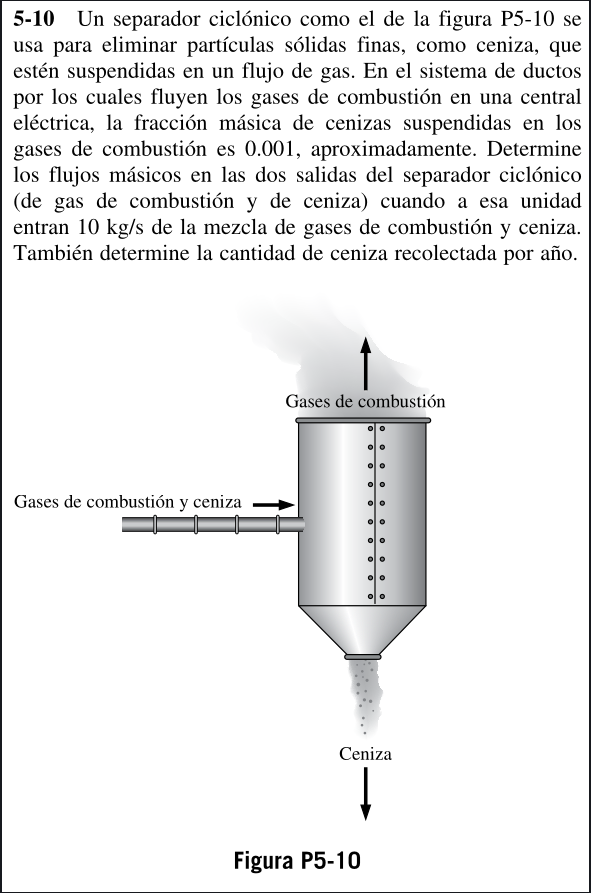

In [4]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales - Vapor saturado R134 - A
x_masica_cenizas_gases_combustion = 1/1000
masa_total_in = 10          # kg / s
#   Desarrollo - régimen estacionario

#   Objetivos : flujos masicos de salida [=] m/s ; ceniza recolectada en el año
m_cenizas_out = masa_total_in * x_masica_cenizas_gases_combustion
m_gases_com_out = masa_total_in - m_cenizas_out

print(f"el flujo masico, para la salidad de gases de combustión es {m_gases_com_out:,.4f} kg/s")
print(f"el flujo masico, para la salidad cenizas {m_cenizas_out:,.4f} kg/s")

m_cenizas_año = m_cenizas_out * (60*60*24*365)

print(f"La cantidad de cenizas generadas en un año por el proceso es {m_cenizas_año:,.1f} kg")
print(f"La cantidad de cenizas generadas en un año por el proceso es {m_cenizas_año/1000:,.1f} Ton")

Realizado por Exergia Code : 
el flujo masico, para la salidad de gases de combustión es 9.9900 kg/s
el flujo masico, para la salidad cenizas 0.0100 kg/s
La cantidad de cenizas generadas en un año por el proceso es 315,360.0 kg
La cantidad de cenizas generadas en un año por el proceso es 315.4 Ton


# Pagina 228 , 36 - Kenneth Wark

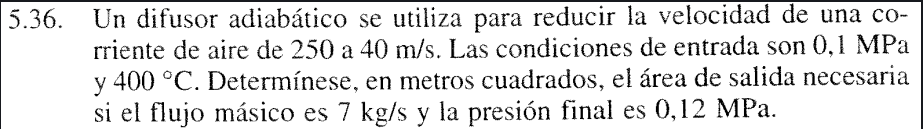

In [5]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales
vel_in = 250            # m / s
P_in = 0.1 * (1000)     # kPa ; 0.1 mPa ; 1 bar     
T_in = 400 + 273.15     # K

#   Condiciones finales
vel_out = 40            # m / s
P_out = 0.12 * (1000)   # kPa ; 0.12 MPa , 1.2 bar 

#   Desarrollo
m_dot = 7               # kg / s
Q_transf = 0
PM_aire = 28.97
R_gas = 8.3145 / (PM_aire)    # kPa . m³ / kg . K

#   Objetivos : A_out [=] m²
print(f"la temperatura a la entrada del difusor es {T_in:,.4f} K")

T_1 = 670 # K
T_2 = 683 # K
h_1 = 681.14 # kJ/kg
h_2 = 691.82 # kJ/kg

h_in = resultado_interpolacion(T_in , T_1, T_2, h_1, h_2)
print(f"el valor de la entalpía en la entrada del difusor es {h_in:,.4f} kJ/kg")
delta_ec = (((vel_in**2)-(vel_out**2))/2) / 1000 # kJ/kg

h_out = h_in + delta_ec
print(f"el valor de la entalpía a la salida del difusor es {h_out:,.4f} kJ/kg")

T_1 = 710 # K
T_2 = 720 # K
h_1 = 724.04 # kJ/kg
h_2 = 734.82 # kJ/kg

T_out = resultado_interpolacion(h_out, h_1, h_2, T_1, T_2)
print(f"la temperatura a la salida del difusor es {T_out:,.4f} K")

vesp_out = (R_gas * T_out) / P_out
A_out = (m_dot * vesp_out) / vel_out

print(f"el area de salida del difusor es {A_out:,.6f} m²")

Realizado por Exergia Code : 
la temperatura a la entrada del difusor es 673.1500 K
el valor de la entalpía en la entrada del difusor es 685.4940 kJ/kg
el valor de la entalpía a la salida del difusor es 715.9440 kJ/kg
la temperatura a la salida del difusor es 726.2742 K
el area de salida del difusor es 0.303980 m²


# Pagina 254, 30 - Çengel Yunus

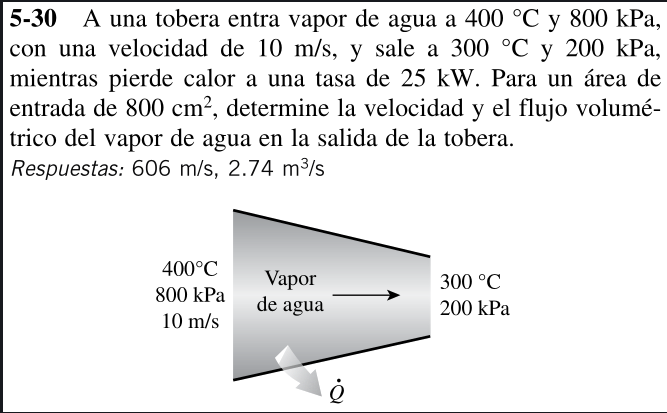

In [6]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales - vapor de agua
T_in = 400 + 273.15         # K
P_in = 800                  # kPa ; 0.8 MPa
vel_in = 10                 # m / s
A_in = 800 * (1/(100**2))  # m²

#   Condiciones finales
T_out = 300 + 273.15        # K
P_out = 200                 # kPa ; 0.2 MPa

#   Desarrollo
Q_out = 25                  # kJ / s

#   Objetivos  : vel_out [=] m/s ; caudal_out [=] m³ / s
h_in = 3267.7 # kJ /kg
h_out = 3072.1 # kJ /kg
vesp_in = 0.38429 # m³ /kg
vesp_out = 1.31623 # m³ /kg

m_dot = (vel_in * A_in) / vesp_in 
print(f"el flujo másico es {m_dot:,.4f} kg/s")

delta_h = (h_out - h_in) * (1000)
q_out = (Q_out / m_dot) * (1000)

vel_out_2_2 = ((vel_in**2)/2) + ( -delta_h - q_out)
vel_out = np.sqrt(vel_out_2_2 * 2)

print(f"la velocidad del fluido a la salida es {vel_out:,.4f} m/s")

caudal_out = m_dot * vesp_out

print(f"caudal a la salida es {caudal_out:,.4f} m³/s")


Realizado por Exergia Code : 
el flujo másico es 2.0818 kg/s
la velocidad del fluido a la salida es 606.0378 m/s
caudal a la salida es 2.7401 m³/s
